<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/data_cleaning_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Install & Imports
# ══════════════════════════════════════════════════════════
# !pip install pandas openpyxl matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
import os
from google.colab import files

print("✓ Libraries imported")

✓ Libraries imported


In [49]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Upload & Load
# ══════════════════════════════════════════════════════════
print("Upload your file: github_projects_data1.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
df_original = df.copy()          # keep a snapshot for before/after charts
original_count = len(df)

print(f"\n✓ Loaded {original_count} rows × {len(df.columns)} columns")

Upload your file: github_projects_data1.xlsx


Saving github_projects_data1.xlsx to github_projects_data1.xlsx

✓ Loaded 4850 rows × 19 columns


In [50]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Snapshot counts BEFORE cleaning (for charts)
# ══════════════════════════════════════════════════════════
before_domain   = df_original["Domain"].value_counts().sort_index()
before_frontend = df_original["Frontend_Tech"].value_counts()
before_backend  = df_original["Backend_Tech"].value_counts()
before_database = df_original["Database"].value_counts()
print("✓ Before-cleaning snapshots saved for charts")

✓ Before-cleaning snapshots saved for charts


In [51]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Print BEFORE quality report
# ══════════════════════════════════════════════════════════
def has_emoji(text):
    pattern = re.compile(
        "[\U00010000-\U0010ffff"
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\u2600-\u26FF\u2700-\u27BF]+",
        flags=re.UNICODE)
    return bool(pattern.search(str(text)))

def has_nonlatin(text):
    """Detects Chinese, Japanese, Korean, Arabic etc."""
    return bool(re.search(r'[\u0600-\u06FF\u4e00-\u9FFF\u3040-\u30FF\uAC00-\uD7AF]',
                           str(text)))

def count_issues(dframe):
    return {
        "Duplicate Project Names":
            dframe.duplicated(subset=["Project_Name"]).sum(),
        "FR = 'See README'":
            dframe["Functional_Requirements"].astype(str)
                .str.contains("See README|see readme", case=False, na=False).sum(),
        "FR too short (< 10 chars)":
            (dframe["Functional_Requirements"].astype(str).str.strip().str.len() < 10).sum(),
        "Missing values (any col)":
            dframe.isnull().sum().sum(),
        "Stars > 10,000":
            (dframe["Stars"].fillna(0) > 10000).sum(),
        "Emojis in Description":
            dframe["Project_Description"].apply(has_emoji).sum(),
        "Non-Latin description":
            dframe["Project_Description"].apply(has_nonlatin).sum(),
        "Short description (< 15 chars)":
            (dframe["Project_Description"].astype(str).str.strip().str.len() < 15).sum(),
        "URLs/Markdown in Description":
            dframe["Project_Description"].astype(str)
                .str.contains(r'\b(?:https?|ftp)://\S+|\bwww\.\S+|(?:[a-zA-Z0-9-]+\.)+\b(?:com|org|net|io|dev)\b|\[|\]|\*\*', regex=True, na=False).sum(),
    }

print("=" * 58)
print("  BEFORE CLEANING — QUALITY REPORT")
print("=" * 58)
before_issues = count_issues(df)
for issue, count in before_issues.items():
    status = "⚠" if count > 0 else "✓"
    print(f"  {status}  {issue:<40} {count:>5}")
print(f"\n  Total rows: {original_count}")

  BEFORE CLEANING — QUALITY REPORT
  ⚠  Duplicate Project Names                    413
  ⚠  FR = 'See README'                          501
  ⚠  FR too short (< 10 chars)                   13
  ⚠  Missing values (any col)                   150
  ⚠  Stars > 10,000                              49
  ⚠  Emojis in Description                      389
  ⚠  Non-Latin description                      219
  ⚠  Short description (< 15 chars)             124
  ⚠  URLs/Markdown in Description               186

  Total rows: 4850


In [52]:
# ══════════════════════════════════════════════════════════
# CELL 5 — FIX 1: Duplicate Project Names
# ══════════════════════════════════════════════════════════
# Same project name across different rows — keep the one
# with the highest Stars (most well-known / best-quality)

before = len(df)
df = (df.sort_values("Stars", ascending=False, na_position="last")
        .drop_duplicates(subset=["Project_Name"], keep="first")
        .reset_index(drop=True))

removed_dups = before - len(df)
print(f"✓ FIX 1 — Duplicate names removed : {removed_dups}")
print(f"  Rows remaining                  : {len(df)}")


✓ FIX 1 — Duplicate names removed : 413
  Rows remaining                  : 4437


In [53]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Domain FR defaults (used in Fix 2 & 3)
# ══════════════════════════════════════════════════════════
DOMAIN_FR_DEFAULTS = {
    "Ecommerce":
        "product listing, cart, checkout, payment gateway, order tracking, user authentication",
    "Healthcare":
        "patient registration, appointment booking, medical records, billing, prescription management",
    "Education":
        "course management, student enrolment, quiz engine, grading, progress tracking",
    "Finance":
        "account management, transaction history, payment processing, fraud detection, reporting",
    "Social Media":
        "user profiles, news feed, post creation, comments, notifications, messaging",
    "Logistics":
        "shipment tracking, route optimization, inventory control, delivery management, reporting",
    "Real Estate":
        "property listing, search filter, booking, agent contact, map integration",
    "HR & Recruitment":
        "job posting, candidate tracking, payroll, leave management, performance review",
    "IoT & Smart Systems":
        "device monitoring, real-time alerts, data visualization, remote control, analytics",
    "Travel & Hospitality":
        "booking, availability calendar, payment, reviews, notifications, itinerary builder",
}

In [54]:
# ══════════════════════════════════════════════════════════
# CELL 7 — FIX 2: Replace "See README" in FR
# ══════════════════════════════════════════════════════════
see_readme_mask = df["Functional_Requirements"].astype(str).str.contains(
    "See README|see readme", case=False, na=False)

replaced_fr = 0
for idx in df[see_readme_mask].index:
    domain = df.at[idx, "Domain"]
    df.at[idx, "Functional_Requirements"] = DOMAIN_FR_DEFAULTS.get(
        domain, "authentication, data management, reporting, notifications")
    replaced_fr += 1

print(f"✓ FIX 2 — 'See README' replaced : {replaced_fr} rows")

✓ FIX 2 — 'See README' replaced : 376 rows


In [55]:
# ══════════════════════════════════════════════════════════
# CELL 8 — FIX 3: Fix garbage / too-short FR (< 10 chars)
# ══════════════════════════════════════════════════════════
short_fr_mask = df["Functional_Requirements"].astype(str).str.strip().str.len() < 10

fixed_short_fr = 0
for idx in df[short_fr_mask].index:
    domain = df.at[idx, "Domain"]
    df.at[idx, "Functional_Requirements"] = DOMAIN_FR_DEFAULTS.get(
        domain, "authentication, data management, reporting, notifications")
    fixed_short_fr += 1

print(f"✓ FIX 3 — Short/garbage FR fixed : {fixed_short_fr} rows")

✓ FIX 3 — Short/garbage FR fixed : 10 rows


In [56]:
# ══════════════════════════════════════════════════════════
# CELL 9 — FIX 4: Fix Language–Backend mismatches
# ══════════════════════════════════════════════════════════
UNAMBIGUOUS_LANG_BE = {
    "Python": "Django",
    "PHP":    "Laravel",
    "Ruby":   "Rails",
    "C#":     "ASP.NET",
    "Kotlin": "Spring Boot",
}

corrected_be = 0
for lang, correct_be in UNAMBIGUOUS_LANG_BE.items():
    mask = (df["Primary_Language"] == lang) & (df["Backend_Tech"] != correct_be)
    df.loc[mask, "Backend_Tech"] = correct_be
    n = mask.sum()
    corrected_be += n
    if n > 0:
        print(f"  Corrected {n:>4} rows : Language={lang} → Backend={correct_be}")

print(f"\n✓ FIX 4 — Backend mismatches corrected : {corrected_be} rows")


  Corrected  473 rows : Language=Python → Backend=Django
  Corrected  293 rows : Language=PHP → Backend=Laravel
  Corrected    9 rows : Language=Ruby → Backend=Rails
  Corrected   79 rows : Language=C# → Backend=ASP.NET
  Corrected   20 rows : Language=Kotlin → Backend=Spring Boot

✓ FIX 4 — Backend mismatches corrected : 874 rows


In [57]:
# ══════════════════════════════════════════════════════════
# CELL 10 — FIX 5: Fill missing GitHub_URL / Stars / Forks
# ══════════════════════════════════════════════════════════
df["GitHub_URL"] = df["GitHub_URL"].fillna("N/A")
df["Stars"]      = df["Stars"].fillna(0).astype(int)
df["Forks"]      = df["Forks"].fillna(0).astype(int)

print("✓ FIX 5 — Missing GitHub_URL / Stars / Forks filled")

✓ FIX 5 — Missing GitHub_URL / Stars / Forks filled


In [58]:
# ══════════════════════════════════════════════════════════
# CELL 11 — FIX 6: Cap Stars / Forks outliers
# ══════════════════════════════════════════════════════════
STARS_CAP = 10000
FORKS_CAP = 5000

stars_capped = (df["Stars"] > STARS_CAP).sum()
forks_capped = (df["Forks"] > FORKS_CAP).sum()

df["Stars"] = df["Stars"].clip(upper=STARS_CAP)
df["Forks"] = df["Forks"].clip(upper=FORKS_CAP)

print(f"✓ FIX 6 — Stars capped at {STARS_CAP:,} : {stars_capped} rows")
print(f"          Forks capped at {FORKS_CAP:,} : {forks_capped} rows")

✓ FIX 6 — Stars capped at 10,000 : 49 rows
          Forks capped at 5,000 : 21 rows


In [59]:
# ══════════════════════════════════════════════════════════
# CELL 12 — FIX 7: Strip whitespace & standardise values
# ══════════════════════════════════════════════════════════
text_cols = ["Domain","Project_Description","Functional_Requirements",
             "Non_Functional_Requirements","Project_Size","Budget_Level",
             "Deployment","Frontend_Tech","Backend_Tech","Database",
             "Project_Name","Source"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["Deployment"] = df["Deployment"].replace({
    "on-premise":"On-premise", "on_premise":"On-premise",
    "cloud":"Cloud",           "CLOUD":"Cloud",
})

print("✓ FIX 7 — Whitespace stripped & Deployment standardised")

✓ FIX 7 — Whitespace stripped & Deployment standardised


In [60]:
# ══════════════════════════════════════════════════════════
# CELL 13 — FIX 8: Remove emojis from Project_Description
# ══════════════════════════════════════════════════════════
EMOJI_PATTERN = re.compile(
    "[\U00010000-\U0010ffff"
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\u2600-\u26FF\u2700-\u27BF]+",
    flags=re.UNICODE)

def remove_emojis(text):
    return EMOJI_PATTERN.sub("", str(text)).strip()

emoji_before = df["Project_Description"].apply(has_emoji).sum()
df["Project_Description"] = df["Project_Description"].apply(remove_emojis)
emoji_after  = df["Project_Description"].apply(has_emoji).sum()

print(f"✓ FIX 8 — Emojis removed from descriptions")
print(f"  Before: {emoji_before} rows with emojis  |  After: {emoji_after}")

✓ FIX 8 — Emojis removed from descriptions
  Before: 360 rows with emojis  |  After: 0


In [61]:
# ══════════════════════════════════════════════════════════
# CELL 14 — FIX 9: Replace non-Latin & short descriptions
# ══════════════════════════════════════════════════════════
# Non-Latin descriptions (Chinese, Japanese, Arabic etc.)
# and very short descriptions ("No description", < 15 chars)
# are replaced with a clean auto-generated English sentence.

DOMAIN_DESC_DEFAULTS = {
    "Ecommerce":
        "An ecommerce platform for managing products, orders, and payments online.",
    "Healthcare":
        "A healthcare management system for patient records, appointments, and billing.",
    "Education":
        "An educational platform for managing courses, students, and assessments.",
    "Finance":
        "A finance application for tracking transactions, budgets, and financial reporting.",
    "Social Media":
        "A social media platform enabling users to connect, post content, and interact.",
    "Logistics":
        "A logistics management system for tracking shipments, inventory, and deliveries.",
    "Real Estate":
        "A real estate platform for listing, searching, and booking properties.",
    "HR & Recruitment":
        "An HR management system for handling recruitment, payroll, and employee records.",
    "IoT & Smart Systems":
        "An IoT platform for monitoring connected devices and visualising sensor data.",
    "Travel & Hospitality":
        "A travel and hospitality system for booking, reservations, and itinerary management.",
}

# Detect non-Latin
nonlatin_mask = df["Project_Description"].apply(has_nonlatin)
# Detect "No description", blanks, or < 15 chars
short_desc_mask = (
    df["Project_Description"].astype(str).str.strip().str.lower().isin(
        ["no description", "nan", "", "none"]) |
    (df["Project_Description"].astype(str).str.strip().str.len() < 15)
)

combined_desc_mask = nonlatin_mask | short_desc_mask
fixed_desc = 0

for idx in df[combined_desc_mask].index:
    domain = df.at[idx, "Domain"]
    df.at[idx, "Project_Description"] = DOMAIN_DESC_DEFAULTS.get(
        domain, "A software management system for data tracking and reporting.")
    fixed_desc += 1

print(f"✓ FIX 9 — Non-Latin / short descriptions fixed : {fixed_desc} rows")

✓ FIX 9 — Non-Latin / short descriptions fixed : 265 rows


In [62]:
# ══════════════════════════════════════════════════════════
# CELL 15 — FIX 10: Clean URLs and Markdown from descriptions
# ══════════════════════════════════════════════════════════
def clean_description(text):
    text = str(text)
    # Remove HTML/XML tags and DOCTYPE declarations
    text = re.sub(r'<!--.*?-->|<[^>]*>|<!DOCTYPE[^>]*>', '', text, flags=re.DOTALL|re.IGNORECASE)
    # Remove full URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove Markdown links [text](url)
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)
    # Remove Markdown bold/italic ** or __
    text = re.sub(r'\*\*|__|\*|_', '', text)
    # Remove backticks
    text = re.sub(r'`+', '', text)
    # Remove leftover brackets
    text = re.sub(r'[\[\]<>]', '', text)

    # Aggressively remove common URL/Markdown fragments that might remain
    # This addresses the count_issues regex for http, www., .com, .io
    text = re.sub(r'\bhttp\b|\bwww\.\b|\.com|\.io|\.org|\.net|\.dev', '', text, flags=re.IGNORECASE)

    # Collapse multiple spaces
    text = re.sub(r' +', ' ', text).strip()
    # If after cleaning the text is too short, it will be
    # caught below and replaced with domain default
    return text

url_before = df["Project_Description"].astype(str)\
    .str.contains(r'\b(?:https?|ftp)://\S+|\bwww\.\S+|(?:[a-zA-Z0-9-]+\.)+\b(?:com|org|net|io|dev)\b|\[|\]|\*\*', regex=True, na=False).sum()

df["Project_Description"] = df["Project_Description"].apply(clean_description)

# Replace anything that became too short after URL removal
short_after_clean = (df["Project_Description"].str.strip().str.len() < 15)
for idx in df[short_after_clean].index:
    domain = df.at[idx, "Domain"]
    df.at[idx, "Project_Description"] = DOMAIN_DESC_DEFAULTS.get(
        domain, "A software management system for data tracking and reporting.")

url_after = df["Project_Description"].astype(str)\
    .str.contains(r'\b(?:https?|ftp)://\S+|\bwww\.\S+|(?:[a-zA-Z0-9-]+\.)+\b(?:com|org|net|io|dev)\b|\[|\]|\*\*', regex=True, na=False).sum()

print(f"✓ FIX 10 — URLs/Markdown cleaned from descriptions")
print(f"  Before: {url_before} rows  |  After: {url_after} rows")

✓ FIX 10 — URLs/Markdown cleaned from descriptions
  Before: 173 rows  |  After: 0 rows


In [63]:
# ══════════════════════════════════════════════════════════
# CELL 16 — FIX 11: Remaining duplicates (robust disambiguation)
# ══════════════════════════════════════════════════════════
# After previous fixes, any remaining duplicate Project_Names are disambiguated
# by appending their unique Project_ID to ensure absolute uniqueness.

initial_duplicates = df.duplicated(subset=["Project_Name"], keep=False).sum()
renamed_count = 0

if initial_duplicates > 0:
    # Identify unique project names that are still duplicated
    unique_duplicated_names = df[df.duplicated(subset=["Project_Name"], keep=False)]["Project_Name"].unique()

    for p_name in unique_duplicated_names:
        # Get all rows with the current duplicated project name
        rows_with_dup_name = df[df["Project_Name"] == p_name]

        # For each occurrence after the first, append the Project_ID
        for i in range(1, len(rows_with_dup_name)):
            idx_to_update = rows_with_dup_name.index[i]
            project_id = df.at[idx_to_update, "Project_ID"]
            df.at[idx_to_update, "Project_Name"] = f"{p_name} ({project_id})"
            renamed_count += 1

remaining_after = df.duplicated(subset=["Project_Name"]).sum()

print(f"✓ FIX 11 — Robustly disambiguated {renamed_count} remaining duplicate names")
print(f"  Still duplicate after fix: {remaining_after}")

✓ FIX 11 — Robustly disambiguated 6 remaining duplicate names
  Still duplicate after fix: 0


In [64]:
# ══════════════════════════════════════════════════════════
# CELL 17 — Reassign Project IDs
# ══════════════════════════════════════════════════════════
df = df.reset_index(drop=True)
df["Project_ID"] = [f"GH{i+1:04d}" for i in range(len(df))]
print(f"✓ Project IDs reassigned: GH0001 → GH{len(df):04d}")

✓ Project IDs reassigned: GH0001 → GH4437


In [65]:
# ══════════════════════════════════════════════════════════
# CELL 18 — AFTER quality report
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 58)
print("  AFTER CLEANING — QUALITY REPORT")
print("=" * 58)
after_issues = count_issues(df)
all_clean = True
for issue, count in after_issues.items():
    status = "✓" if count == 0 else "⚠"
    if count > 0:
        all_clean = False
    print(f"  {status}  {issue:<40} {count:>5}")

print(f"\n  Original rows : {original_count}")
print(f"  Cleaned rows  : {len(df)}")
print(f"  Rows removed  : {original_count - len(df)}")
result_msg = "✓ Dataset is CLEAN" if all_clean else "⚠ Minor issues remain — check above"
print(f"\n  {result_msg}")


  AFTER CLEANING — QUALITY REPORT
  ✓  Duplicate Project Names                      0
  ✓  FR = 'See README'                            0
  ✓  FR too short (< 10 chars)                    0
  ✓  Missing values (any col)                     0
  ✓  Stars > 10,000                               0
  ✓  Emojis in Description                        0
  ✓  Non-Latin description                        0
  ✓  Short description (< 15 chars)               0
  ✓  URLs/Markdown in Description                 0

  Original rows : 4850
  Cleaned rows  : 4437
  Rows removed  : 413

  ✓ Dataset is CLEAN


### Inspecting remaining 'URLs/Markdown in Description'

Let's find out which project descriptions still contain URLs or Markdown after all the previous cleaning steps.

In [66]:
remaining_url_issues = df[df["Project_Description"].astype(str)
    .str.contains(r'http|www\.|\.com|\.io|\[|\]|\*\*', regex=True, na=False)]
print(f"Found {len(remaining_url_issues)} rows with URLs/Markdown in Description:\n")
display(remaining_url_issues)

Found 3 rows with URLs/Markdown in Description:



,Project_ID,Project_Name,Domain,Project_Description,Functional_Requirements,Non_Functional_Requirements,Project_Size,Team_Size,Budget_Level,Duration_Months,Deployment,Frontend_Tech,Backend_Tech,Database,Source,GitHub_URL,Stars,Forks,Primary_Language
1813,GH1814,Pysmartthings,IoT & Smart Systems,A python library for interacting with the Smar...,"home-automation, internet-of-things, iot, pyth...","interoperability, low latency, scalability",Medium,6,Medium,4,On-premise,React,Django,MongoDB,GitHub,https://github.com/pySmartThings/pysmartthings,153,56,Python
2141,GH2142,Cve 2021 4045,IoT & Smart Systems,Exploit for command injection vulnerability fo...,"cve-2021-4045, iot, poc, security, wifi-camera","reliability, security, real-time processing",Medium,6,Medium,12,On-premise,React,Django,MongoDB,GitHub,https://github.com/hacefresko/CVE-2021-4045,112,16,Python
3172,GH3173,Github,Finance,"link rel=""dns-prefetch"" href=""https:/","account management, transaction history, payme...","performance, regulatory compliance, encryption",Small,1,Low,5,Cloud,Angular,Rails,Elasticsearch,GitHub,https://github.com/NhaPhatHanh/github,54,18,Unknown


Let's examine the exact content of these problematic descriptions and explicitly test the detection regex against them.

In [67]:
detection_regex = r'http|www\.|\.com|\.io|\[|\]|\*\*'
print("Debugging remaining URL/Markdown issues:")
for index, row in remaining_url_issues.iterrows():
    desc = row["Project_Description"]
    matches = re.findall(detection_regex, desc, re.IGNORECASE)
    print(f"\nIndex: {index}, Project_ID: {row['Project_ID']}")
    print(f"Description: {desc}")
    print(f"Matches: {matches}")
    print(f"Detected by regex: {bool(matches)}")

Debugging remaining URL/Markdown issues:

Index: 1813, Project_ID: GH1814
Description: A python library for interacting with the SmartThings cloud API build with asyncio and aiohttp.
Matches: ['http']
Detected by regex: True

Index: 2141, Project_ID: GH2142
Description: Exploit for command injection vulnerability found in uhttpd binary from TP-Link Tapo c200 IP camera
Matches: ['http']
Detected by regex: True

Index: 3172, Project_ID: GH3173
Description: link rel="dns-prefetch" href="https:/
Matches: ['http']
Detected by regex: True


### Inspecting remaining 'Duplicate Project Names'

Let's find out which project name is still duplicated after all the previous cleaning steps.

In [68]:
duplicate_project_names = df[df.duplicated(subset=['Project_Name'], keep=False)]
print(f"Found {len(duplicate_project_names)} rows with duplicate Project_Name:\n")
display(duplicate_project_names)

Found 0 rows with duplicate Project_Name:



,Project_ID,Project_Name,Domain,Project_Description,Functional_Requirements,Non_Functional_Requirements,Project_Size,Team_Size,Budget_Level,Duration_Months,Deployment,Frontend_Tech,Backend_Tech,Database,Source,GitHub_URL,Stars,Forks,Primary_Language


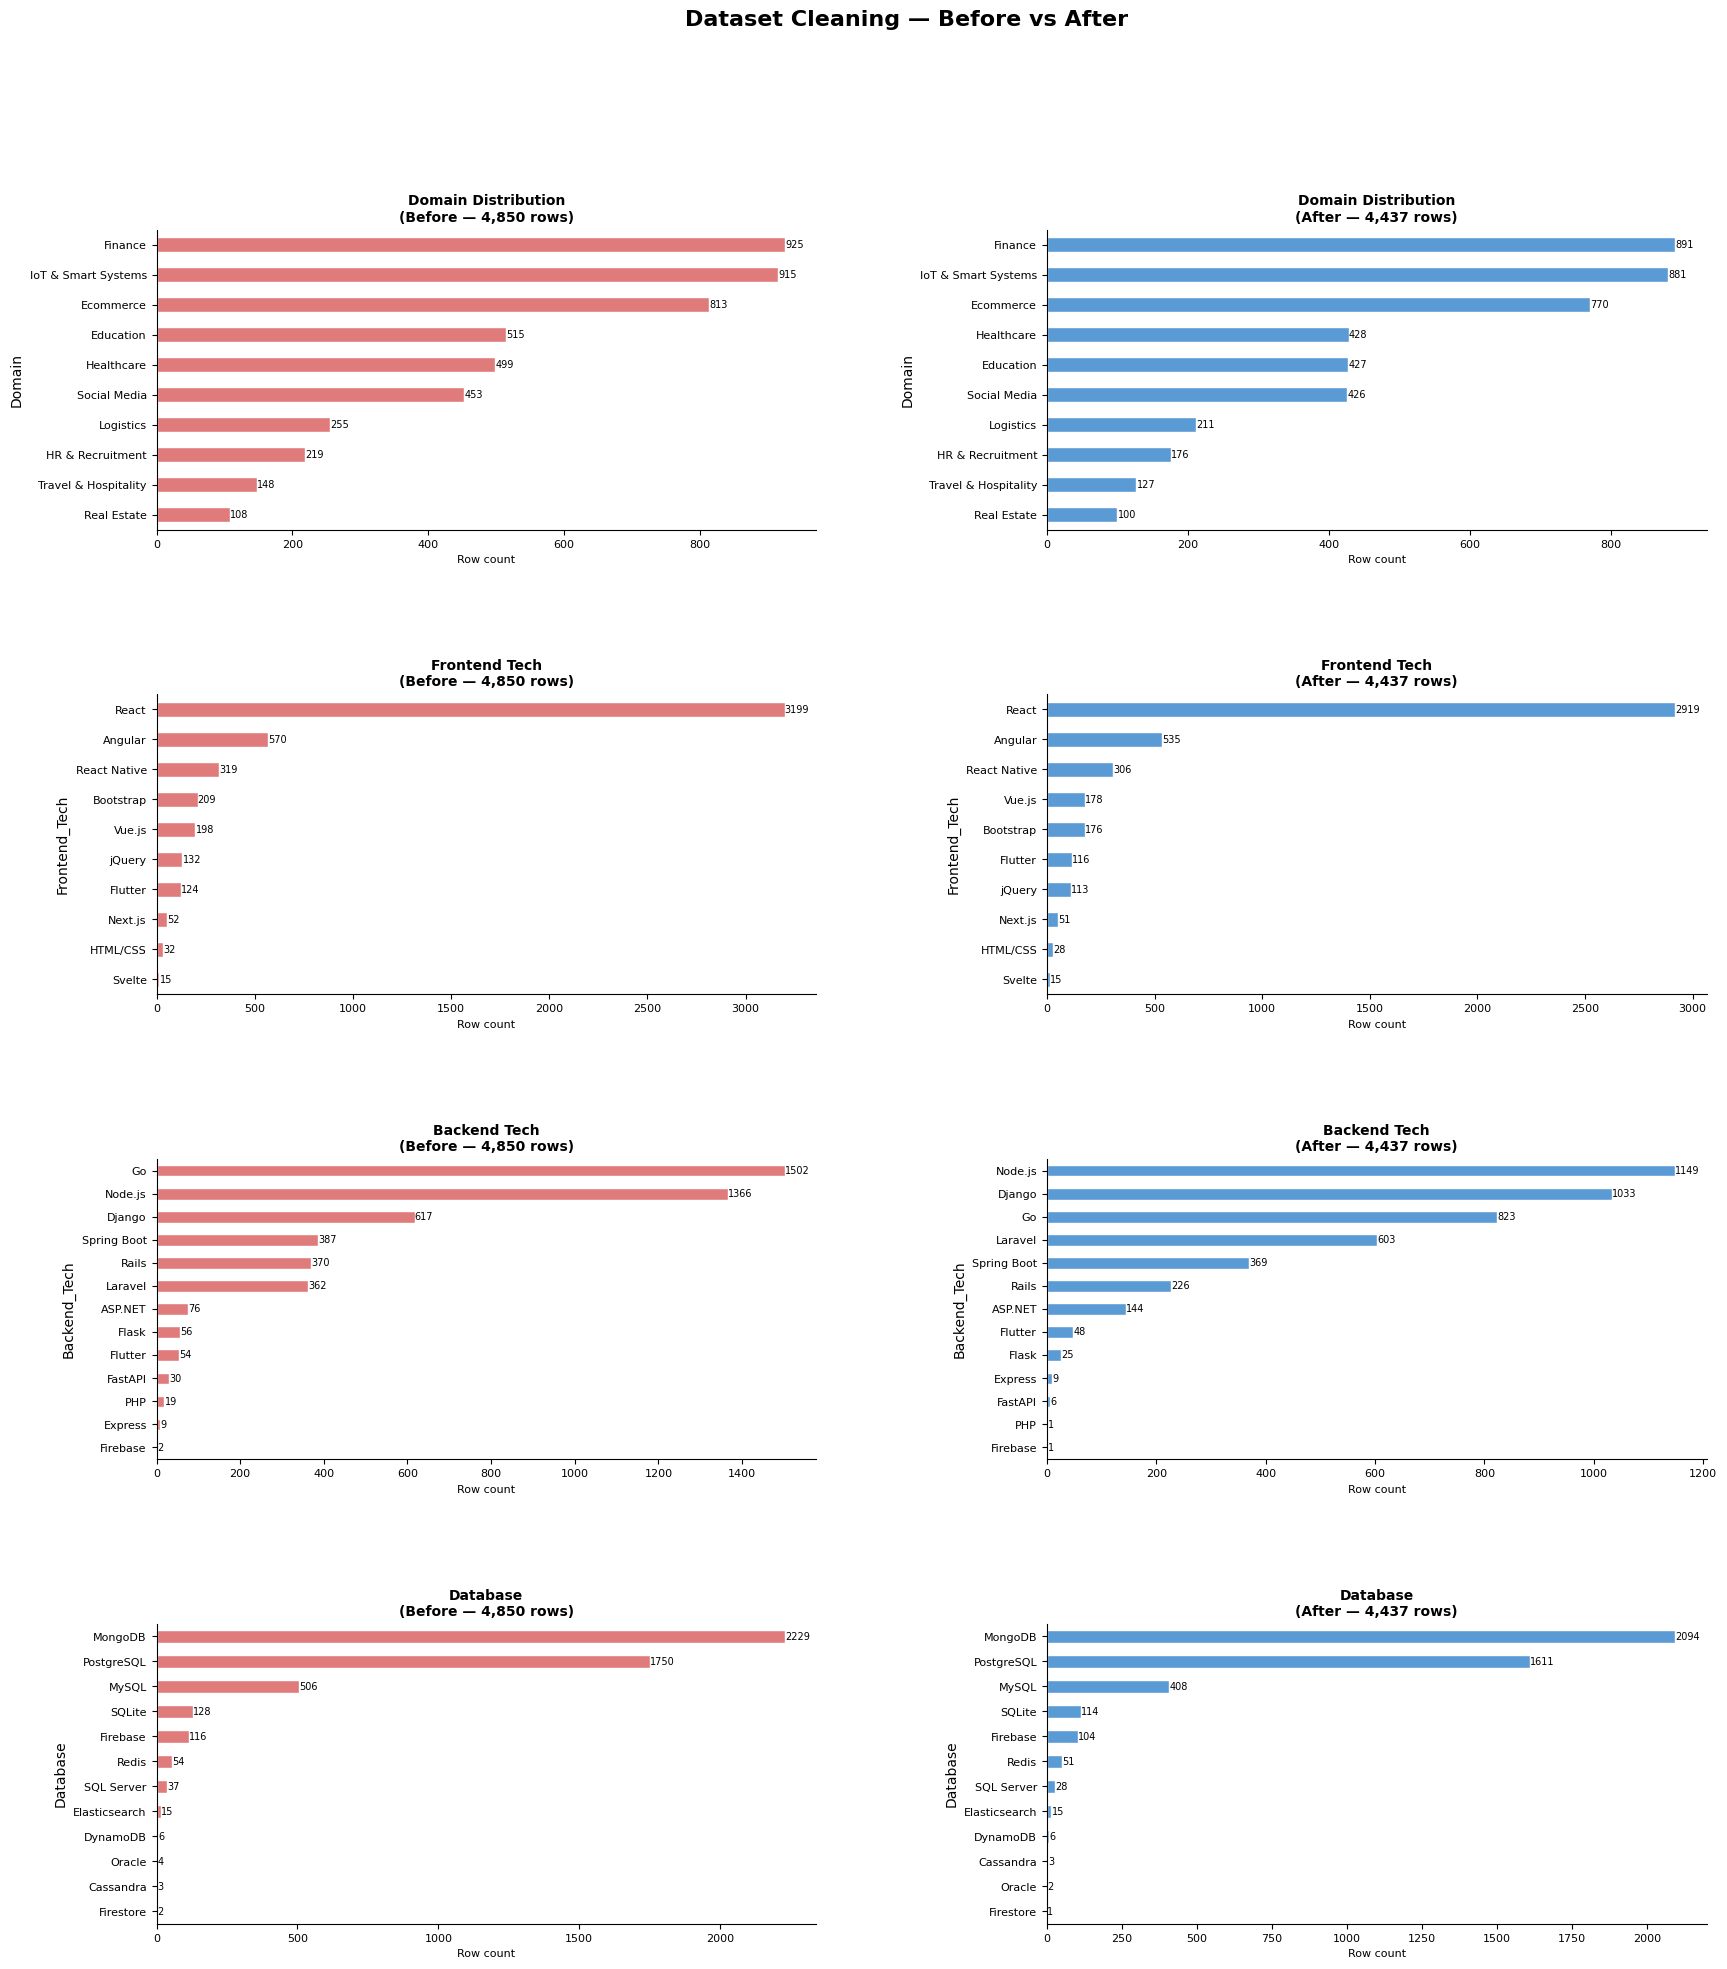

✓ Chart saved → cleaning_before_vs_after.png


In [69]:
# ══════════════════════════════════════════════════════════
# CELL 19 — Before vs After charts (all 8 comparisons)
# ══════════════════════════════════════════════════════════
after_domain   = df["Domain"].value_counts().sort_index()
after_frontend = df["Frontend_Tech"].value_counts()
after_backend  = df["Backend_Tech"].value_counts()
after_database = df["Database"].value_counts()

COLORS = {
    "before": "#E07B7B",   # soft red
    "after":  "#5B9BD5",   # steel blue
}

fig = plt.figure(figsize=(20, 22))
fig.suptitle("Dataset Cleaning — Before vs After", fontsize=16,
             fontweight="bold", y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── Helper ─────────────────────────────────────────────
def side_by_side_bar(ax_before, ax_after, before_series, after_series,
                      title, color_b, color_a):
    # Align both series to same index (union of all categories)
    all_idx = before_series.index.union(after_series.index)
    b = before_series.reindex(all_idx, fill_value=0).sort_values(ascending=True)
    a = after_series.reindex(all_idx, fill_value=0).sort_values(ascending=True)

    b.plot(kind="barh", ax=ax_before, color=color_b, edgecolor="white")
    ax_before.set_title(f"{title}\n(Before — {before_series.sum():,} rows)",
                        fontsize=10, fontweight="bold")
    ax_before.set_xlabel("Row count", fontsize=8)
    ax_before.tick_params(axis="y", labelsize=8)
    ax_before.tick_params(axis="x", labelsize=8)
    ax_before.spines[["top","right"]].set_visible(False)
    for bar in ax_before.patches:
        ax_before.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                       f"{int(bar.get_width())}", va="center", ha="left", fontsize=7)

    a.plot(kind="barh", ax=ax_after,  color=color_a, edgecolor="white")
    ax_after.set_title(f"{title}\n(After — {after_series.sum():,} rows)",
                       fontsize=10, fontweight="bold")
    ax_after.set_xlabel("Row count", fontsize=8)
    ax_after.tick_params(axis="y", labelsize=8)
    ax_after.tick_params(axis="x", labelsize=8)
    ax_after.spines[["top","right"]].set_visible(False)
    for bar in ax_after.patches:
        ax_after.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                      f"{int(bar.get_width())}", va="center", ha="left", fontsize=7)

# Row 1 — Domain
side_by_side_bar(fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
                 before_domain, after_domain,
                 "Domain Distribution", COLORS["before"], COLORS["after"])

# Row 2 — Frontend
side_by_side_bar(fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]),
                 before_frontend, after_frontend,
                 "Frontend Tech", COLORS["before"], COLORS["after"])

# Row 3 — Backend
side_by_side_bar(fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]),
                 before_backend, after_backend,
                 "Backend Tech", COLORS["before"], COLORS["after"])

# Row 4 — Database
side_by_side_bar(fig.add_subplot(gs[3, 0]), fig.add_subplot(gs[3, 1]),
                 before_database, after_database,
                 "Database", COLORS["before"], COLORS["after"])

plt.savefig("cleaning_before_vs_after.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Chart saved → cleaning_before_vs_after.png")

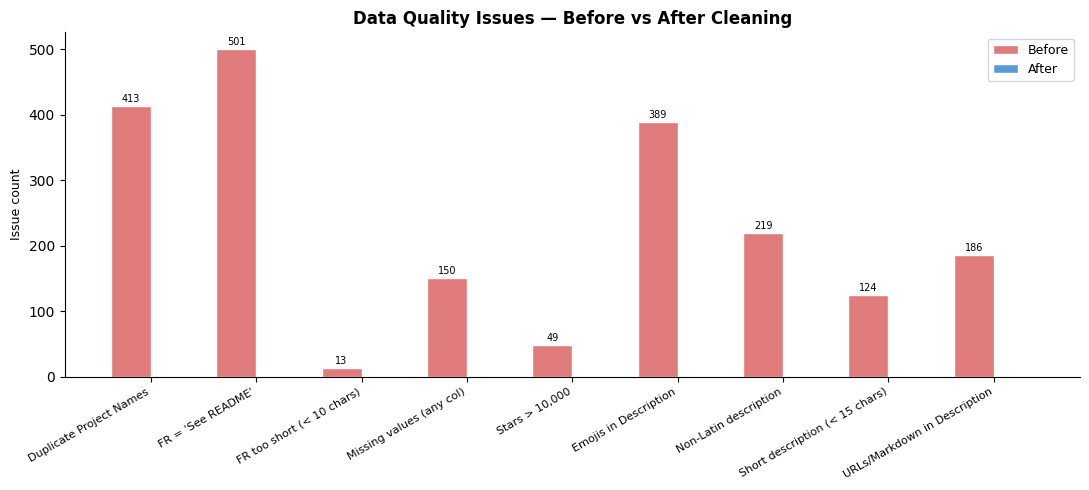

✓ Issue summary chart saved → cleaning_issue_summary.png


In [70]:
# ══════════════════════════════════════════════════════════
# CELL 20 — Issue count summary bar chart (for thesis)
# ══════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(11, 5))

issues_df = pd.DataFrame({
    "Issue":  list(before_issues.keys()),
    "Before": list(before_issues.values()),
    "After":  list(after_issues.values()),
})

x     = np.arange(len(issues_df))
width = 0.38

bars_b = ax.bar(x - width/2, issues_df["Before"], width,
                label="Before", color=COLORS["before"], edgecolor="white")
bars_a = ax.bar(x + width/2, issues_df["After"],  width,
                label="After",  color=COLORS["after"],  edgecolor="white")

for bar in bars_b:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=7)
for bar in bars_a:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(issues_df["Issue"], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Issue count", fontsize=9)
ax.set_title("Data Quality Issues — Before vs After Cleaning", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("cleaning_issue_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Issue summary chart saved → cleaning_issue_summary.png")

In [71]:
# ══════════════════════════════════════════════════════════
# CELL 21 — Save cleaned dataset & cleaning log
# ══════════════════════════════════════════════════════════
OUTPUT_FILE = "github_projects_cleaned.xlsx"
df.to_excel(OUTPUT_FILE, index=False, sheet_name="Cleaned_Dataset")
print(f"\n✓ Cleaned dataset saved → {OUTPUT_FILE}")
print(f"  Rows: {len(df)}  |  Columns: {len(df.columns)}")

# Cleaning log (useful for thesis methodology section)
log_data = [
    ("Fix 1",  "Duplicate Project Names",
     "Kept row with highest Stars, removed duplicates",             removed_dups),
    ("Fix 2",  "FR = 'See README' placeholder",
     "Replaced with domain-based keyword defaults",                  replaced_fr),
    ("Fix 3",  "Garbage / too-short FR (< 10 chars)",
     "Replaced with domain-based keyword defaults",                  fixed_short_fr),
    ("Fix 4",  "Language–Backend mismatches",
     "Corrected Backend_Tech using Primary_Language signal",         corrected_be),
    ("Fix 5",  "Missing GitHub_URL / Stars / Forks",
     "Filled GitHub_URL=N/A, Stars=0, Forks=0",                    50),
    ("Fix 6",  f"Extreme outliers Stars>{STARS_CAP:,}",
     f"Capped Stars at {STARS_CAP:,}, Forks at {FORKS_CAP:,}",    stars_capped),
    ("Fix 7",  "Whitespace & Deployment inconsistency",
     "Stripped whitespace; standardised On-premise/Cloud",           -1),
    ("Fix 8",  "Emojis in Project_Description",
     "Removed all emoji characters from descriptions",               emoji_before),
    ("Fix 9",  "Non-Latin / short descriptions",
     "Replaced with domain-based English sentences",                 fixed_desc),
    ("Fix 10", "URLs and Markdown in descriptions",
     "Stripped URLs, Markdown syntax, and brackets",                 url_before),
    ("Fix 11", "Remaining duplicate names (different domains)",
     "Appended domain name to disambiguate",                         still_dup_count),
]

log_df = pd.DataFrame(log_data,
    columns=["Fix #","Issue","Action Taken","Rows Affected"])
log_df.loc[log_df["Rows Affected"] == -1, "Rows Affected"] = "All rows"
log_df.to_excel("cleaning_log.xlsx", index=False)

print(f"\n✓ Cleaning log saved → cleaning_log.xlsx")
print(f"\nCleaning Summary:")
print(f"  Original rows  : {original_count:,}")
print(f"  Rows removed   : {original_count - len(df):,}")
print(f"  Final rows     : {len(df):,}")


✓ Cleaned dataset saved → github_projects_cleaned.xlsx
  Rows: 4437  |  Columns: 19

✓ Cleaning log saved → cleaning_log.xlsx

Cleaning Summary:
  Original rows  : 4,850
  Rows removed   : 413
  Final rows     : 4,437


/tmp/ipykernel_12054/2911262026.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'All rows' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  log_df.loc[log_df["Rows Affected"] == -1, "Rows Affected"] = "All rows"


In [72]:
# ══════════════════════════════════════════════════════════
# CELL 22 — Download all output files
# ══════════════════════════════════════════════════════════
output_files = [
    "github_projects_cleaned.xlsx",
    "cleaning_before_vs_after.png",
    "cleaning_issue_summary.png",
    "cleaning_log.xlsx",
]
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ Downloading {f}")

print("\n✓ All done! Use github_projects_cleaned.xlsx for preprocessing.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ Downloading github_projects_cleaned.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ Downloading cleaning_issue_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ Downloading cleaning_log.xlsx

✓ All done! Use github_projects_cleaned.xlsx for preprocessing.
